#Weather Temperature Prediction and Forecasting

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

#Data Loading and Cleaning

In [167]:
# Load dataset (skip metadata rows and clean column names)
file_path = "dly1475.csv"
with open(file_path, "r") as f:
    for i, line in enumerate(f):
        # Look for line that contains multiple expected column names
        if "date" in line.lower() and "," in line and "maxtp" in line.lower():
            header_row = i
            break
df = pd.read_csv(file_path, skiprows=header_row)
df.columns = df.columns.str.strip()
print(df.head())

        date  maxtp  mintp  gmin rain     cbl  wdsp  hm  ddhm  hg    soil  \
0  01-Oct-09   12.4    8.2   6.1    0  1013.9   4.6   8     0  12   13.37   
1  02-Oct-09   15.7    8.1   5.9  0.4  1008.9  10.1  16   230  26   12.66   
2  03-Oct-09   13.9    7.7  10.1  0.9    1000  12.5  20   240  32   12.32   
3  04-Oct-09   12.4    6.6   4.1    0  1002.7   4.1   8   260  13  11.205   
4  05-Oct-09   16.0    5.4   1.3    0   998.4   5.7  13   150  18   12.24   

    pe evap smd_wd smd_md smd_pd glorad  
0  0.8    1    0.8    0.8    0.8    489  
1  1.1  1.5    1.4    1.4    1.4    573  
2  1.1  1.6    1.6    1.6    1.6    669  
3  0.9  1.2    2.5    2.5    2.5    645  
4  1.2  1.7    3.6    3.6    3.7   1066  


In [168]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5661 entries, 0 to 5660
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    5661 non-null   object 
 1   maxtp   5661 non-null   float64
 2   mintp   5661 non-null   float64
 3   gmin    5661 non-null   object 
 4   rain    5661 non-null   object 
 5   cbl     5661 non-null   object 
 6   wdsp    5661 non-null   object 
 7   hm      5661 non-null   int64  
 8   ddhm    5661 non-null   int64  
 9   hg      5661 non-null   int64  
 10  soil    5661 non-null   object 
 11  pe      5661 non-null   object 
 12  evap    5661 non-null   object 
 13  smd_wd  5661 non-null   object 
 14  smd_md  5661 non-null   object 
 15  smd_pd  5661 non-null   object 
 16  glorad  5661 non-null   object 
dtypes: float64(2), int64(3), object(12)
memory usage: 752.0+ KB
None


In [169]:
print(df.describe())

             maxtp        mintp           hm         ddhm           hg
count  5661.000000  5661.000000  5661.000000  5661.000000  5661.000000
mean     13.495813     5.824360    15.016252   198.429606    22.129129
std       5.097440     4.708719     5.612998    82.168210     8.515965
min      -7.000000   -13.400000     0.000000     0.000000     1.000000
25%      10.000000     2.300000    11.000000   150.000000    16.000000
50%      13.400000     6.000000    14.000000   210.000000    21.000000
75%      17.200000     9.500000    18.000000   260.000000    27.000000
max      31.000000    17.800000    46.000000   350.000000    67.000000


In [170]:
# Convert date column (format: 01-Oct-09) using %y for 2-digit year
df['date'] = df['date'].astype(str).str.strip()
df['date'] = pd.to_datetime(df['date'], format="%d-%b-%y", errors='coerce')
df = df.sort_values('date')
df = df.set_index('date')
print(df.isnull().sum())

maxtp     0
mintp     0
gmin      0
rain      0
cbl       0
wdsp      0
hm        0
ddhm      0
hg        0
soil      0
pe        0
evap      0
smd_wd    0
smd_md    0
smd_pd    0
glorad    0
dtype: int64


In [171]:
print(df.dtypes)

maxtp     float64
mintp     float64
gmin       object
rain       object
cbl        object
wdsp       object
hm          int64
ddhm        int64
hg          int64
soil       object
pe         object
evap       object
smd_wd     object
smd_md     object
smd_pd     object
glorad     object
dtype: object


In [172]:
print(df.duplicated().sum()) #Check for any duplicates

0


In [173]:
#Check for missing dates/rows
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = full_range.difference(df.index)
print("Number of missing dates:", len(missing_dates))

Number of missing dates: 0


In [174]:
# Convert numeric columns stored as object
df = df.apply(pd.to_numeric, errors='coerce')
print(df.isnull().sum())  # should be 0 for each column

maxtp     0
mintp     0
gmin      9
rain      5
cbl       7
wdsp      5
hm        0
ddhm      0
hg        0
soil      9
pe        9
evap      9
smd_wd    9
smd_md    9
smd_pd    9
glorad    7
dtype: int64


In [175]:
# Fill the missing values
df = df.interpolate().ffill().bfill()
print(df.isnull().sum().sum())  # should be 0

0


Missing values were handled using linear interpolation to preserve temporal trends, followed by forward and backward filling to address any remaining edge cases. This approach maintains continuity in the time series while avoiding distortion of the data

#Exploratory Data Analysis
The dataset was explored to understand temporal patterns, distributions, and relationships between variables.

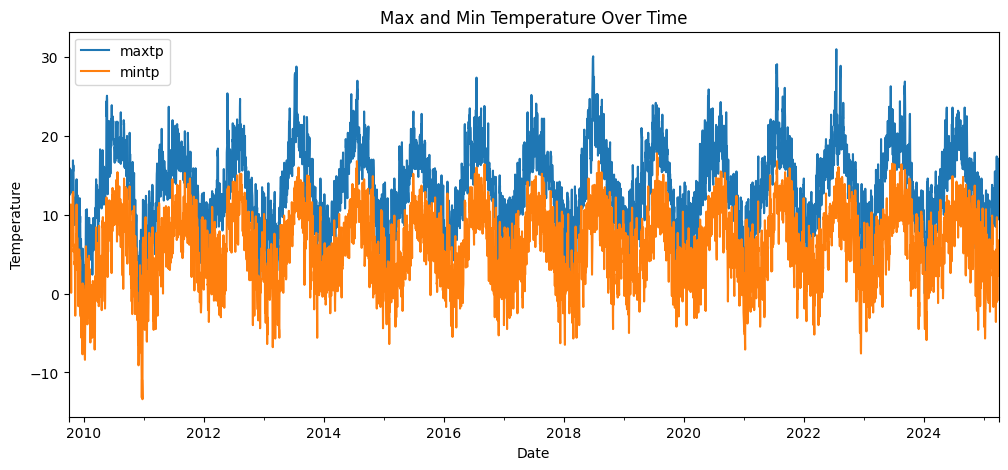

In [176]:
df[['maxtp', 'mintp']].plot(figsize=(12,5))
plt.title("Max and Min Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

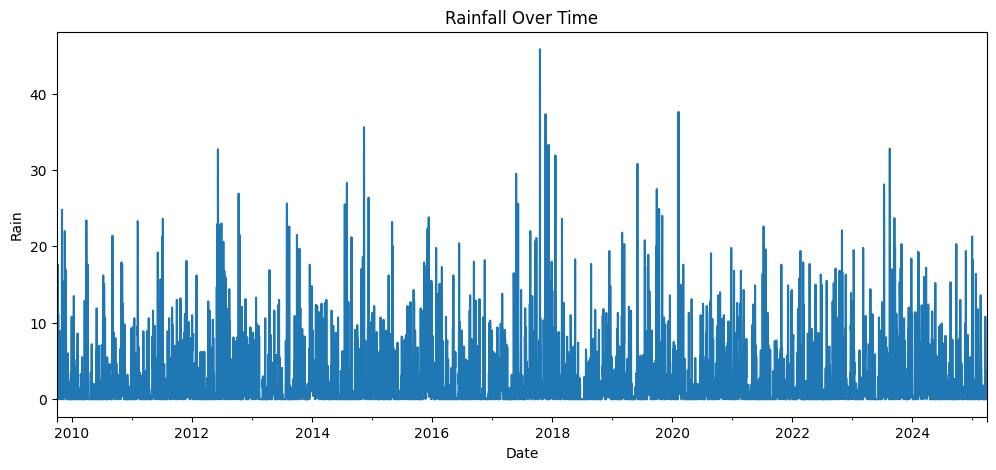

In [177]:
df['rain'].plot(figsize=(12,5))
plt.title("Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rain")
plt.show()

/tmp/ipykernel_16531/2197276132.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample('M').mean()


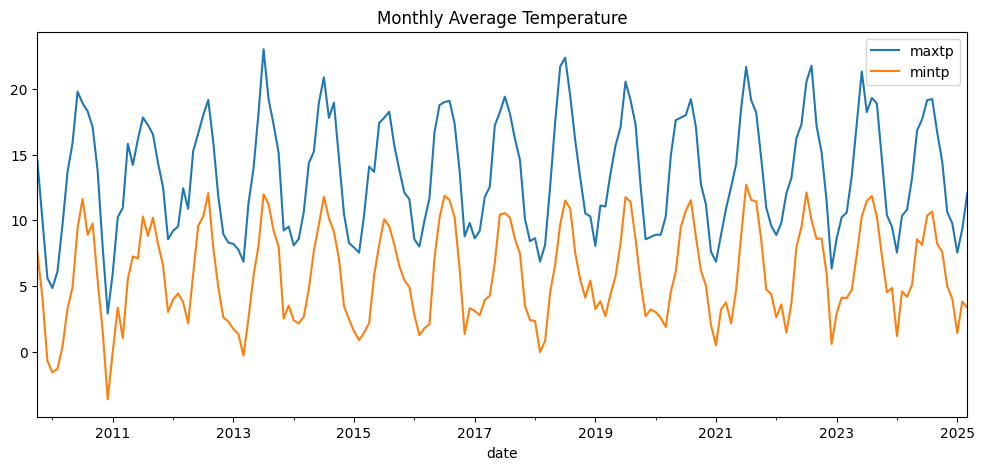

In [178]:
monthly_avg = df.resample('M').mean()
monthly_avg[['maxtp', 'mintp']].plot(figsize=(12,5))
plt.title("Monthly Average Temperature")
plt.show()

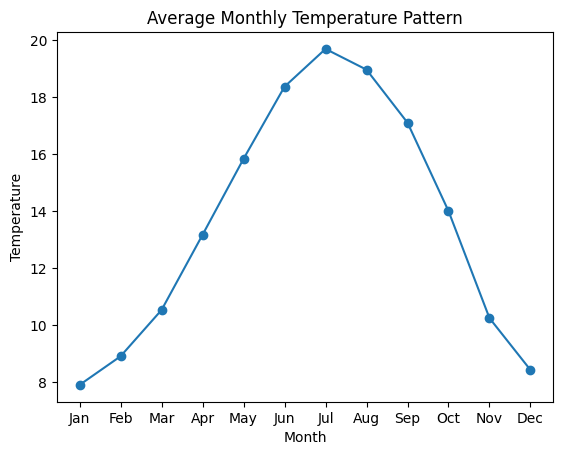

In [179]:
monthly_pattern = df.groupby(df.index.month).mean()
monthly_pattern['maxtp'].plot(marker='o')
plt.title("Average Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

/tmp/ipykernel_16531/1725793504.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = df.resample('Y').mean()


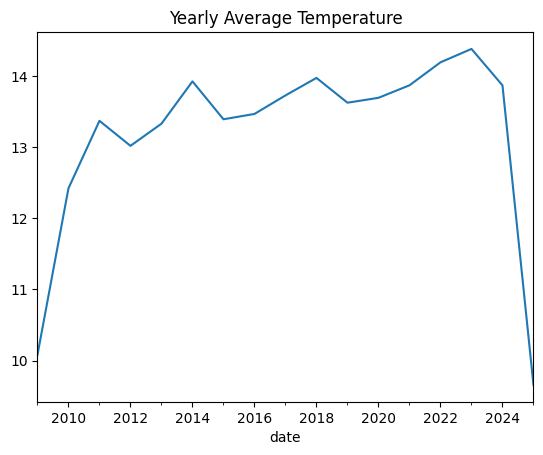

In [180]:
yearly_avg = df.resample('Y').mean()
yearly_avg['maxtp'].plot(title="Yearly Average Temperature")
plt.show()

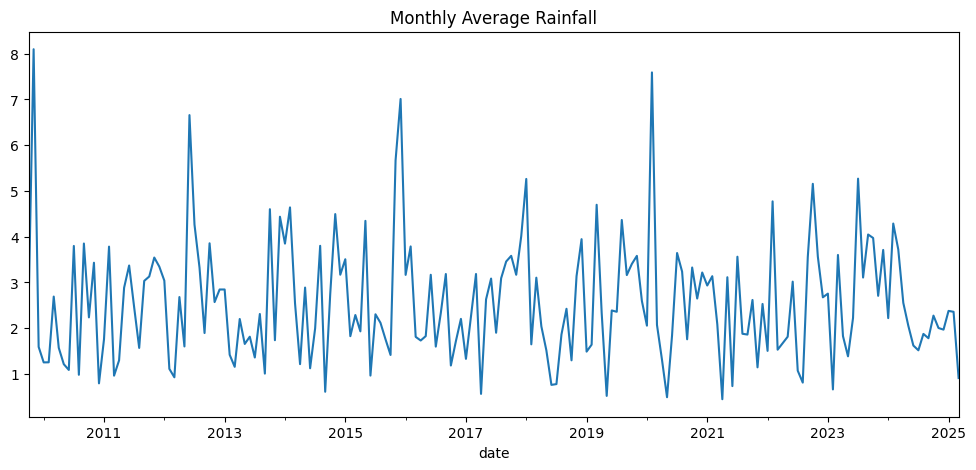

In [181]:
monthly_avg['rain'].plot(figsize=(12,5))
plt.title("Monthly Average Rainfall")
plt.show()

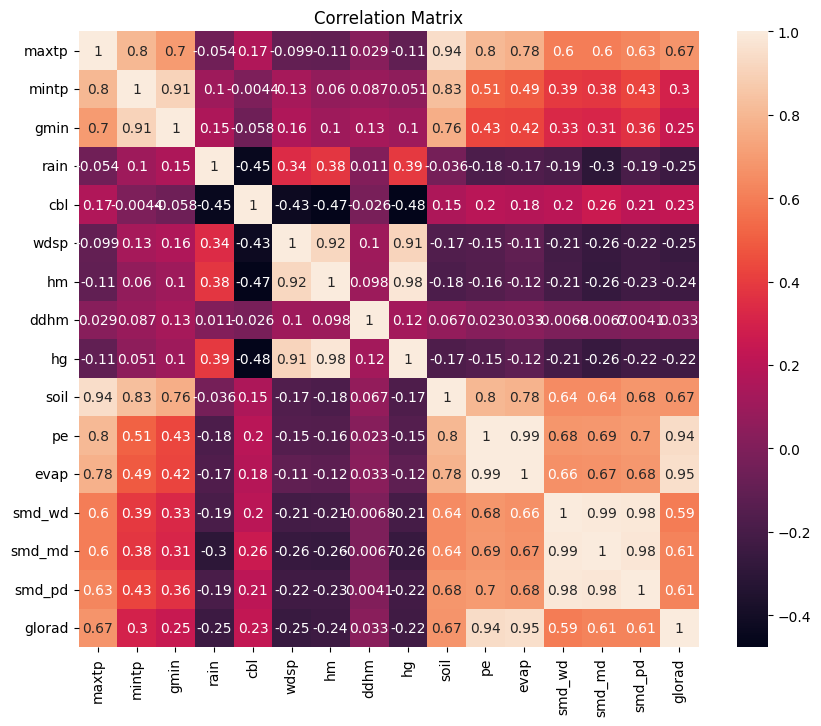

In [182]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

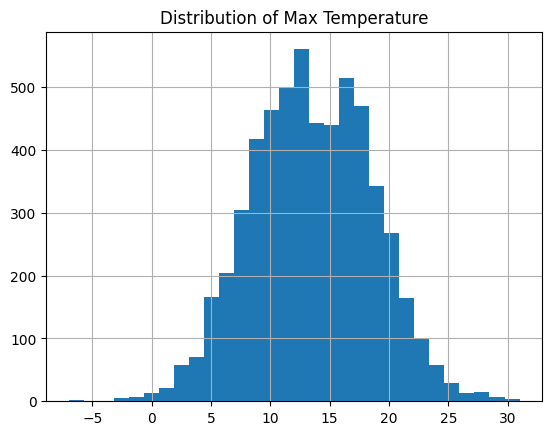

In [183]:
df['maxtp'].hist(bins=30)
plt.title("Distribution of Max Temperature")
plt.show()

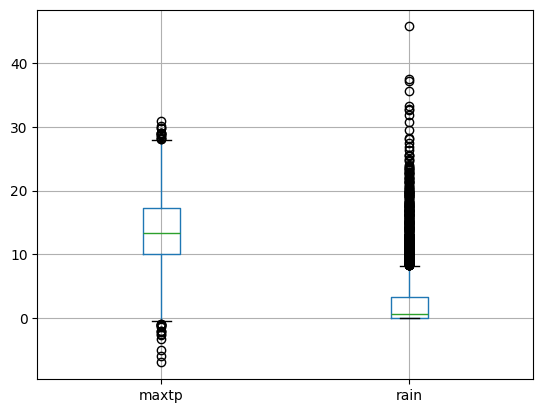

In [184]:
df.boxplot(column=['maxtp', 'rain'])
plt.show()

# Feature Engineering

In [185]:
# Create lag features to capture temporal dependency, rolling mean smooths short-term fluctuations
df_model = df.drop(columns=['mintp', 'gmin'])
df_model['lag1'] = df_model['maxtp'].shift(1)
df_model['lag7'] = df_model['maxtp'].shift(7)
df_model['rolling_mean_7'] = df_model['maxtp'].rolling(7).mean()
df_model['month'] = df_model.index.month

In [186]:
print(df_model.isnull().sum())

maxtp             0
rain              0
cbl               0
wdsp              0
hm                0
ddhm              0
hg                0
soil              0
pe                0
evap              0
smd_wd            0
smd_md            0
smd_pd            0
glorad            0
lag1              1
lag7              7
rolling_mean_7    6
month             0
dtype: int64


In [187]:
df_model = df_model.dropna()

#Modelling

In [188]:
X = df_model.drop(columns=['maxtp'])
y = df_model['maxtp']

In [189]:
models = {
    "Linear Regression": LinearRegression(), # baseline model
    "Decision Tree": DecisionTreeRegressor(max_depth=10), # non-linear model
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42) # ensemble model
}


## Time-Series Cross Validation

TimeSeriesSplit was used to evaluate forecasting models while preserving chronological ordering of observations.

Unlike random cross-validation, TimeSeriesSplit prevents future information leakage and provides a more realistic evaluation of forecasting performance across multiple temporal folds.

In [190]:
def cal_smape(y_true, y_pred):

    return 100 / len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-10)
    )

In [191]:

# TimeSeriesSplit setup
tscv = TimeSeriesSplit(n_splits=5)

results = []

# Train and evaluate each model
for name, model in models.items():

    mae_scores = []
    rmse_scores = []
    r2_scores = []
    smape_scores = []

    # Time series cross-validation
    for train_index, test_index in tscv.split(X):

        X_train_fold, X_test_fold = (
            X.iloc[train_index],
            X.iloc[test_index]
        )

        y_train_fold, y_test_fold = (
            y.iloc[train_index],
            y.iloc[test_index]
        )

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred_fold = model.predict(X_test_fold)

        # Metrics
        mae_scores.append(
            mean_absolute_error(y_test_fold, y_pred_fold)
        )

        rmse_scores.append(
            np.sqrt(
                mean_squared_error(
                    y_test_fold,
                    y_pred_fold
                )
            )
        )

        r2_scores.append(
            r2_score(y_test_fold, y_pred_fold)
        )

        smape_scores.append(
            cal_smape(
                y_test_fold,
                y_pred_fold))

    # Store average scores
    results.append({
        "Model": name,
        "MAE": round(np.mean(mae_scores), 3),
        "RMSE": round(np.mean(rmse_scores), 3),
        "R2 Score": round(np.mean(r2_scores), 3),
        "SMAPE": round(np.mean(smape_scores), 3)
    })

# Results dataframe
results_df = pd.DataFrame(results)

# Sort by RMSE
results_df = results_df.sort_values(
    by="RMSE"
)

print(results_df)

               Model    MAE   RMSE  R2 Score   SMAPE
2      Random Forest  1.131  1.452     0.916  10.288
0  Linear Regression  1.167  1.480     0.913  10.610
1      Decision Tree  1.459  1.877     0.860  13.250


In [192]:


# # Train and evaluate each model (MAE, RMSE, and R² used to assess model performance)
# results = []
# for name, model in models.items():
#     model.fit(X_train, y_train) # Train
#     y_pred = model.predict(X_test) # Predict
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     r2 = r2_score(y_test, y_pred)
#     mape = mean_absolute_percentage_error(
#     y_test,
#     y_pred
# )

# # print("MAPE:", round(mape, 4))
#     results.append({
#         "Model": name,
#         "MAE": mae,
#         "RMSE": rmse,
#         "R2": r2,
#         "MAPE": round(mape, 4)
#     })
# results_df = pd.DataFrame(results)
# print(results_df)
# # Note: TimeSeries cross-validation was considered but not implemented to keep
# # the model simple and within assignment constraints.

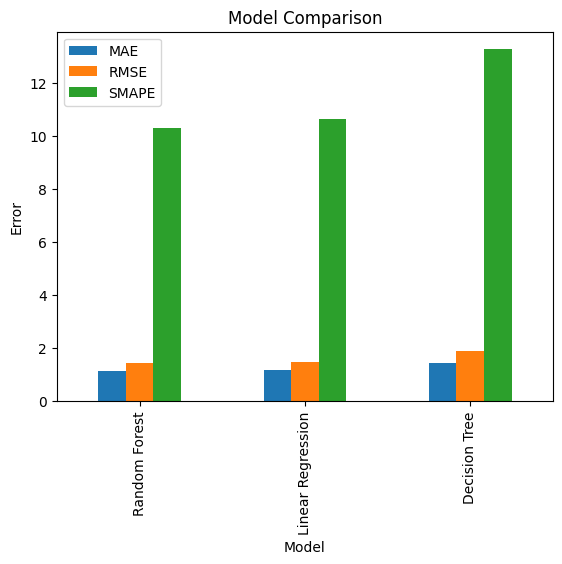

In [193]:
results_df.set_index("Model")[["MAE", "RMSE", "SMAPE"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Error")
plt.show()

In [194]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Performing Model:", best_model_name)

best_model = models[best_model_name]

Best Performing Model: Random Forest


In [195]:
# Final chronological split for final evaluation

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

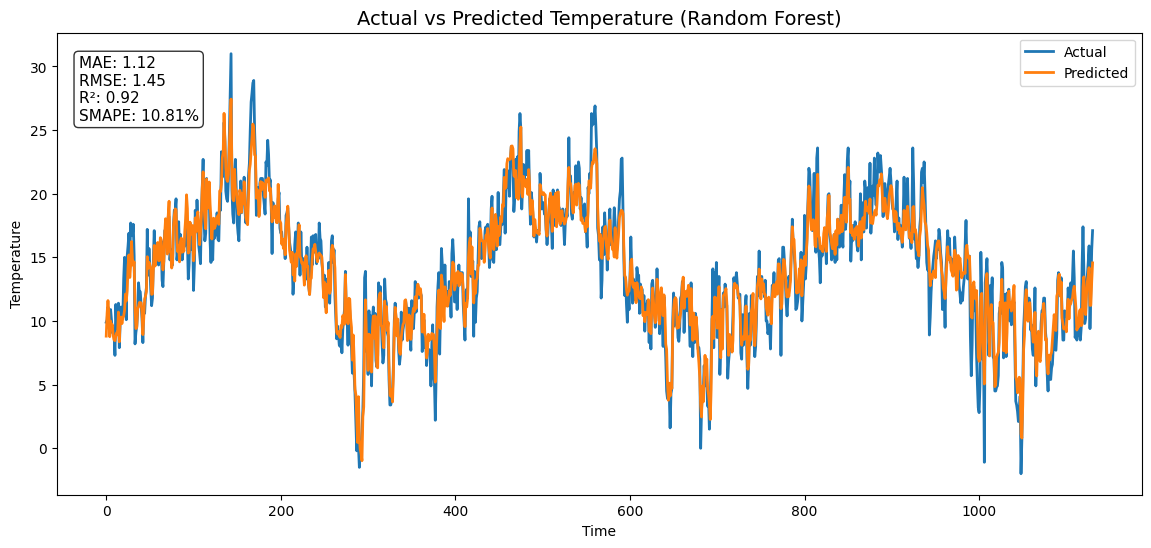

In [196]:
# Random Forest selected as final model due to lowest errors (MAE, RMSE) and ability
# to capture non-linear patterns in temperature data
# best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
# Metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

# SMAPE
smape = 100 / len(y_test) * np.sum(
    2 * np.abs(y_pred - y_test) /
    (np.abs(y_test) + np.abs(y_pred) + 1e-10)
)


# Plot
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Predicted",
    linewidth=2
)

# Title
plt.title(
    "Actual vs Predicted Temperature (Random Forest)",
    fontsize=14
)

plt.xlabel("Time")
plt.ylabel("Temperature")

# Metrics box
metrics_text = (
    f"MAE: {mae:.2f}\n"
    f"RMSE: {rmse:.2f}\n"
    f"R²: {r2:.2f}\n"
    f"SMAPE: {smape:.2f}%"
)

plt.text(
    0.02,
    0.95,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    )
)

plt.legend()

plt.show()



In [197]:
naive_forecast = y_test.shift(1)

naive_mae = mean_absolute_error(
    y_test[1:],
    naive_forecast[1:]
)

print("Naive Forecast MAE:", naive_mae)

Naive Forecast MAE: 1.8153982300884957


In [198]:

arima_model = ARIMA(
    y_train,
    order=(5,1,0)
)

arima_result = arima_model.fit()

arima_pred = arima_result.forecast(
    steps=len(y_test)
)

print(
    "ARIMA MAE:",
    mean_absolute_error(y_test, arima_pred)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MAE: 6.2060173288126785


## Baseline and ARIMA Comparison

A naive persistence forecast and a classical ARIMA forecasting model were implemented as benchmark approaches for comparison.

The Random Forest model outperformed both baseline forecasting methods, achieving substantially lower forecasting error compared to the naive forecast and ARIMA model.

This suggests that machine learning models leveraging lag-based and rolling statistical features were more effective at capturing nonlinear temporal patterns within the weather dataset.

In [199]:
train_pred = best_model.predict(X_train)

train_smape = cal_smape(
    y_train,
    train_pred
)

test_smape = cal_smape(
    y_test,
    y_pred
)

print("Train MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train SMAPE:", round(train_smape, 3))
print("Test SMAPE:", round(test_smape, 3))

Train MAE: 0.39031417200972757
Test MAE: 1.116153846153846
Train SMAPE: 4.104
Test SMAPE: 10.811


## Model Interpretation

Random Forest achieved the best overall predictive performance among the evaluated machine learning models and was therefore selected for forecasting analysis.

Lag-based and rolling statistical features contributed significantly to capturing short-term temporal dependencies within the weather data.

While the forecasting system demonstrates reasonable predictive capability, recursive multi-step forecasting may accumulate error over extended prediction horizons.

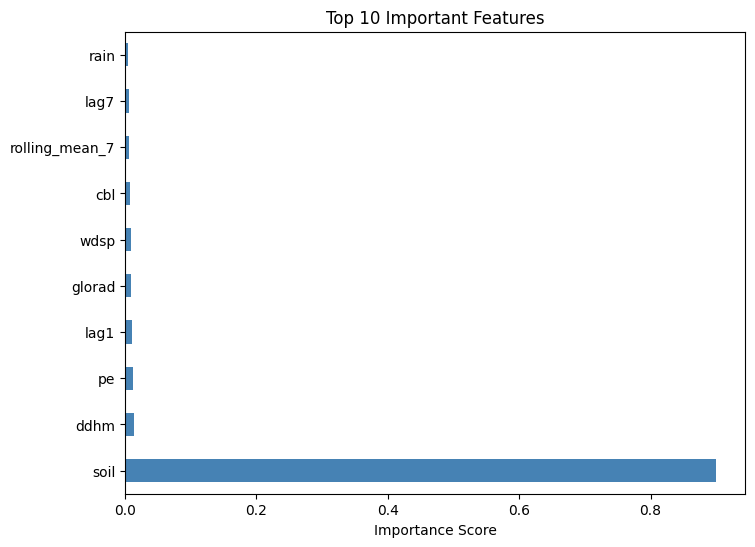

In [200]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(10).plot(
    kind='barh',
    figsize=(8,6),
    color='steelblue'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.show()

In [201]:
# Recursive forecasting: Each predicted value is used to generate the next prediction
def forecast_future(df, model, steps=7):
    df_temp = df.copy()
    predictions = []
    for i in range(steps):
        # Create features for last row
        last_row = df_temp.iloc[-1:]
        lag1 = last_row['maxtp'].values[0]
        lag7 = df_temp['maxtp'].iloc[-7]
        rolling_mean_7 = df_temp['maxtp'].iloc[-7:].mean()
        month = last_row.index.month[0]
        # Create input dataframe
        X_new = pd.DataFrame({
            'lag1': [lag1],
            'lag7': [lag7],
            'rolling_mean_7': [rolling_mean_7],
            'month': [month]
        })
        # Add other features if you kept them
        for col in X.columns:
            if col not in X_new.columns:
                X_new[col] = last_row[col].values[0]
        # Ensure same column order
        X_new = X_new[X.columns]
        # Predict
        y_pred = model.predict(X_new)[0]
        predictions.append(y_pred)
        # Add predicted value to dataframe
        next_date = df_temp.index[-1] + pd.Timedelta(days=1)
        new_row = last_row.copy()
        new_row.index = [next_date]
        new_row['maxtp'] = y_pred
        df_temp = pd.concat([df_temp, new_row])
    return predictions

In [202]:
forecast_1_day = forecast_future(df_model, best_model, steps=1) # 1-day ahead
print("1-day ahead forecast:", forecast_1_day)
forecast_7_days = forecast_future(df_model, best_model, steps=7) # 7-day ahead
print("7-day ahead forecast:", forecast_7_days)

1-day ahead forecast: [np.float64(14.795999999999994)]
7-day ahead forecast: [np.float64(14.795999999999994), np.float64(14.517999999999995), np.float64(14.442999999999998), np.float64(14.509999999999996), np.float64(14.563999999999997), np.float64(14.421999999999999), np.float64(14.555)]


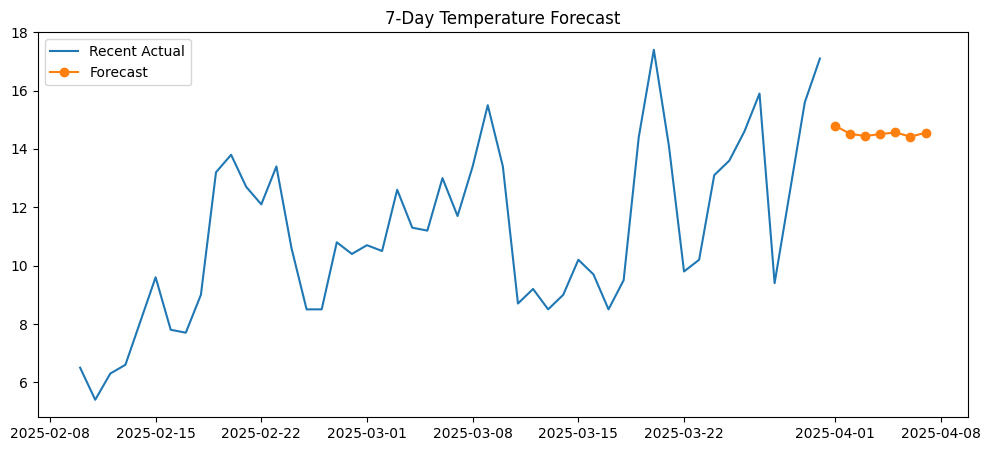

In [203]:
future_dates = pd.date_range(
    start=df_model.index[-1] + pd.Timedelta(days=1),
    periods=7
)
plt.figure(figsize=(12,5))
plt.plot(df_model['maxtp'].iloc[-50:], label="Recent Actual")
plt.plot(future_dates, forecast_7_days, label="Forecast", marker='o')
plt.legend()
plt.title("7-Day Temperature Forecast")
plt.show()

# Limitations:
The model may not fully capture extreme temperature variability, recursive multi-step forecasting can accumulate errors, and the limited feature set may reduce predictive accuracy.